# 01 Overview, activity and structure (Phase 2)
Working notebook. Figures C01-C09 (plus C03b). The story is merged into `eda.ipynb` later.

In [1]:
import sys, pathlib
ROOT = pathlib.Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
%load_ext autoreload
%autoreload 2
import warnings; warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import pandas as pd
from src.viz import set_style, GROUP_COLORS, SUB_COLORS, ACCENT, GRAY, save, finding_title, caption, event_line, highlight_vs_gray
from src.config import AGG, EXT, EVENTS, GROUPS
set_style()

## Data and preparation
**Source.** Arctic Shift archive, six subreddits (r/memes, r/teenagers, r/books, r/explainlikeimfive, r/todayilearned, r/nosurf), January 2012 to September 2026, downloaded with `dataset-collection/arctic_download.py` as hive-partitioned Parquet.

**A sample, not the whole archive.** For every subreddit-month the download takes whole random time slots (about 1,000 comments each) until it holds at least 10,000 comments and 2,000 posts. Months with fewer records are complete. The exact monthly totals were downloaded separately (`_monthly_totals.csv`). This design has three consequences that shape every analysis below:
1. Rates, shares and medians (words per comment, brainrot terms per 10,000 words, sentiment) are estimated from the sample and are fine.
2. Volumes (records per month, comments per post) must come from the exact totals, never from the sample.
3. When months with different sampling fractions are pooled, each row is weighted by `monthly total / sampled rows`. Statistics that need *every* record (authors per month, concentration, daily series) are exact only for r/nosurf, which is complete.

**Submissions and comments** are cleaned and analyzed separately (`type` filter) and then stored in one table with a shared set of columns (`id, type, author_id, ts, subreddit, text, score, link_id, num_comments, slot_start, n_tokens`). Submission text is `title + selftext`, comment text is `body`. One table lets group-level and event-level views (H4) combine both types without repeating the cleaning, while the `type` column keeps the two behaviours apart: a comment and a post are different acts and have very different lengths.

**Cleaning** (each row is counted once, in this order): (1) AutoModerator and accounts whose name ends in "bot"; (2) comments distinguished as moderator or admin (official moderation messages); (3) templated text, meaning the first 100 characters occur 300 or more times in the whole archive (removal notices, rule reminders, a link bot; 88 templates); (4) empty or removed text; (5) spam, meaning 100 or more words with fewer than 15% distinct words (one 2026 burst in r/teenagers alone was 177 comments of about 1,800 words each); (6) duplicate ids. Steps 2, 3 and 5 were added after a word-pair count showed moderator boilerplate and one spam burst among the most frequent items. Timestamps are UTC and authors are hashed. Comments from deleted accounts keep their text (the metrics are about language) but get no `author_id`.

**Tokenizer.** Words are runs of letters, digits and apostrophes in lower-cased text without URLs. Typographic apostrophes are straightened first: without it, "they’re" (common on phone keyboards, more so in recent years) counts as two words and recent text looks longer and different.

In [2]:
cl = pd.read_parquet(AGG / "cleaning_counts.parquet")
cols = ["raw_rows", "dropped_bot", "dropped_moderator", "dropped_template", "dropped_empty_or_removed", "dropped_spam", "dropped_duplicate_id", "final_rows", "kept_with_deleted_author"]
tot = cl.groupby("type")[cols].sum()
tot.loc["all"] = tot.sum()
tot.rename(columns={"raw_rows": "raw rows", "dropped_bot": "- bots", "dropped_moderator": "- moderator messages",
                    "dropped_template": "- templated text", "dropped_empty_or_removed": "- empty/removed",
                    "dropped_spam": "- spam", "dropped_duplicate_id": "- duplicate ids", "final_rows": "= rows kept",
                    "kept_with_deleted_author": "of which deleted account"}).style.format("{:,.0f}")

,raw rows,- bots,- moderator messages,- templated text,- empty/removed,- spam,- duplicate ids,= rows kept,of which deleted account
type,,,,,,,,,
comment,"9,237,205","212,546","63,121","7,175","668,614",487,0,"8,285,262","250,405"
submission,"1,870,257","3,457",0,0,9,72,0,"1,866,719","426,913"
all,"11,107,462","216,003","63,121","7,175","668,623",559,0,"10,151,981","677,318"


**Validation.** Row counts after cleaning equal the raw rows minus every dropped row, for each type and subreddit (`validate.reconcile`), and a pandera schema checks types, ranges and uniqueness on a random sample of 200,000 rows (`validate.SCHEMA`). The matrix below (V01, `validate.missingness_figure`) shows what is missing by design: `author_id` for deleted accounts (about 7%), `num_comments` for comments. Code: `src/validate.py`, `src/io_reddit.py`; guide in `docs/code_guide.md`.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

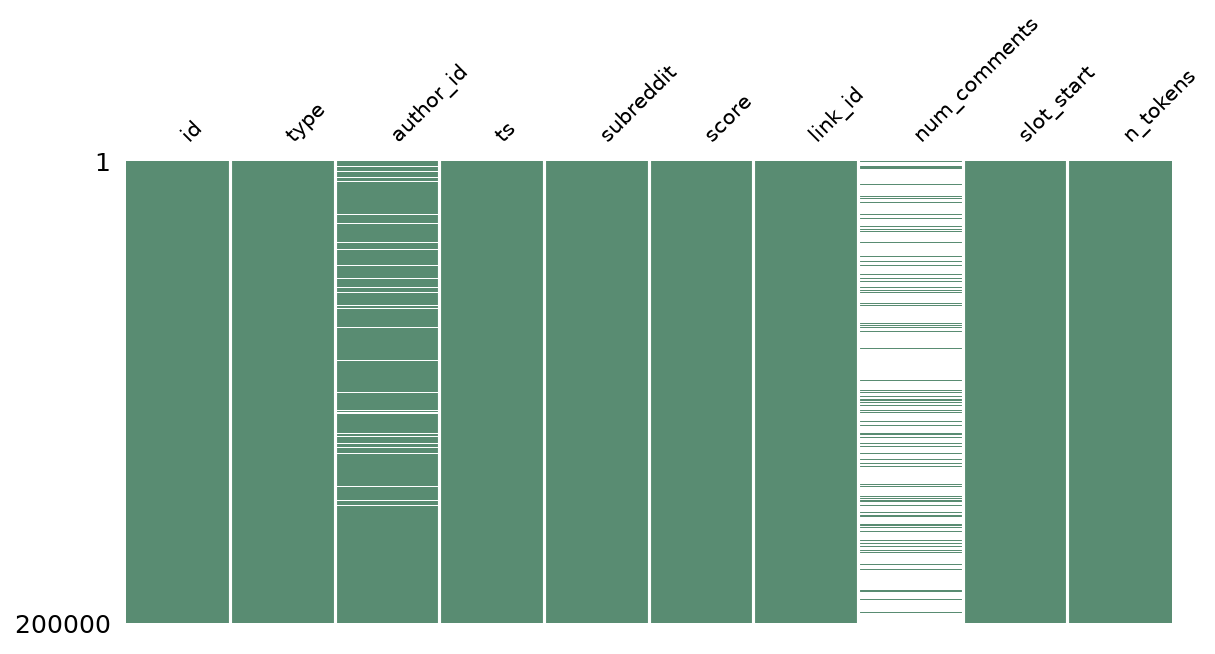

In [3]:
from IPython.display import Image
from src import validate
validate.missingness_figure()
Image(filename=str(ROOT / "figures" / "V01_missingness.png"))

In [4]:
w = pd.read_parquet(AGG / "sample_weights.parquet")
cov = w.groupby(["subreddit", "type"])[["total", "raw_rows"]].sum().unstack("type")
cov.columns = [f"{a} ({b}s)" for a, b in cov.columns]
cov["sample share, all records"] = w.groupby("subreddit")["raw_rows"].sum() / w.groupby("subreddit")["total"].sum()
cov.style.format("{:,.0f}").format({"sample share, all records": "{:.1%}"})

,total (comments),total (submissions),raw_rows (comments),raw_rows (submissions),"sample share, all records"
subreddit,,,,,
books,13137631,890216,1876751.000000,368255.000000,16.0%
explainlikeimfive,21058471,2000253,1852536.000000,369085.000000,9.6%
memes,108528872,11858295,1334537.000000,343402.000000,1.4%
nosurf,478745,56082,478540.000000,56057.000000,100.0%
teenagers,133272831,10305407,1843775.000000,363975.000000,1.5%
todayilearned,69926671,2162300,1851066.000000,369483.000000,3.1%


### Q1. How much activity do our subreddits produce, and how did it change?
**Why we asked:** Every later rate needs a volume context, and the sample hides true volume.

**What we did:** Exact monthly totals from Arctic Shift (not the sample), comments and submissions stacked, six subreddits together. Stacked columns show both the total and the comment/submission split.

**Result:** Activity peaked in July 2020 at 6.6M records a month and fell to 1.4M by September 2026. Over the whole period there are 346.4M comments and 27.3M submissions, about one submission for every 13 comments.

**Interpretation:** The rise from 2018 and the fall after 2022 are visible in the totals; Q2 shows which subreddits drive them. We have not tested why activity fell; platform changes, API protests and migration to other platforms are untested guesses.

**Next question:** Which subreddits carry this volume, and how much of it do we actually hold?

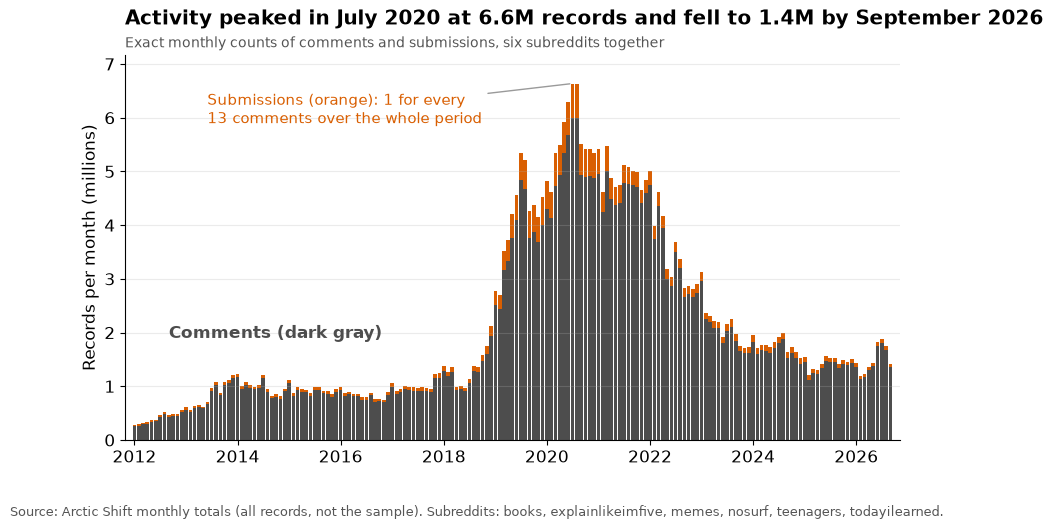

In [5]:
from src import figs_overview as figs
_ = figs.c01()
plt.show()

**Code for C01:** `src/figs_overview.py` function `c01()`; reads `monthly_totals`; built by `python run_pipeline.py aggregates`. All charts and tables: `docs/figure_index.md`, scripts explained in `docs/code_guide.md`.

### Q2. Which subreddits carry the data, and how much of each is in our sample?
**Why we asked:** Q1 showed a big swing; we need to know whose it is, and what the sample can support.

**What we did:** For each subreddit, the share of its records (comments plus submissions) that is in our sample, as stacked bars: dark = in our sample, light = not downloaded, with the counts written next to each bar.

**Result:** r/teenagers (143.6M records) and r/memes (120.4M) hold 71% of the archive, but our sample covers only 1.5% and 1.4% of them. Coverage is 3.1% for r/todayilearned, 9.6% for r/explainlikeimfive, 16.0% for r/books and 100% for r/nosurf.

**Interpretation:** The sample is large in absolute terms (10.2M rows) but thin for the biggest communities. Rates and medians are reliable; anything that needs every record is exact only for r/nosurf. The heavy short-form communities dominate every pooled statistic unless we weight or split by subreddit.

**Next question:** What does a complete community look like? We use r/nosurf as our exact case: who writes in it, and how many.

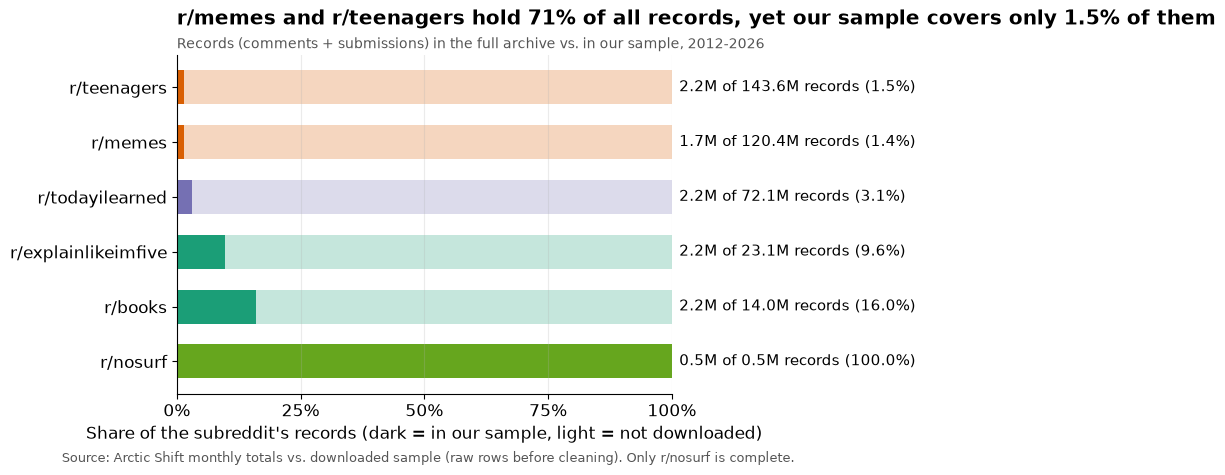

In [6]:
from src import figs_overview as figs
_ = figs.c02()
plt.show()

**Code for C02:** `src/figs_overview.py` function `c02()`; reads `sample_weights`; built by `python run_pipeline.py aggregates`. All charts and tables: `docs/figure_index.md`, scripts explained in `docs/code_guide.md`.

### Q3. How many people take part in r/nosurf, and is the community growing?
**Why we asked:** r/nosurf is the only complete subreddit, so author counts are exact there, and it is the most reflective community in our data.

**What we did:** Distinct commenting authors per month (bots and deleted accounts excluded), with a 3-month mean and the three crisis dates marked. We do not draw this for the other five subreddits: their sample size is fixed, so author counts would only mirror the sampling plan.

**Result:** From about 21 commenters a month in 2012-15 the community grew to about 2,400 in 2025. It plateaued around 1,400 between 2020 and 2023 and rose again from early 2024.

**Interpretation:** Growth is steady, not a one-off jump at a crisis date. A growing audience for a subreddit about quitting social media is a notable fact, but it describes this community only.

**Next question:** How do people who write here differ in how much they write (Q4), and how clean is the data (Q3b)?

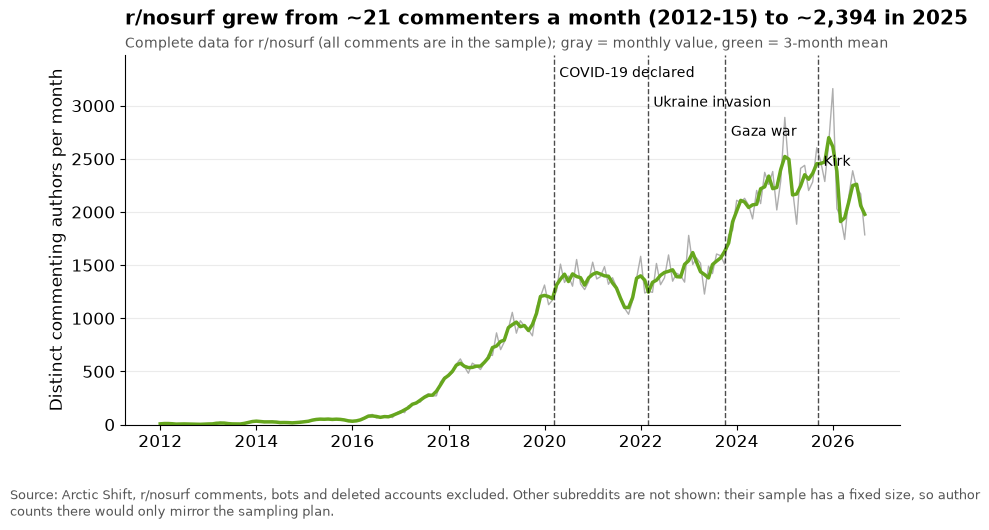

In [7]:
from src import figs_overview as figs
_ = figs.c03()
plt.show()

**Code for C03:** `src/figs_overview.py` function `c03()`; reads `overview_counts`; built by `python run_pipeline.py aggregates`. All charts and tables: `docs/figure_index.md`, scripts explained in `docs/code_guide.md`.

### Q3b. How much of each subreddit is removed, deleted or written by bots?
**Why we asked:** The cleaning step drops these rows; if the share changes over time, it could bias text metrics.

**What we did:** Share of sampled comments that are removed/deleted text or from bots, per subreddit and month (raw sample before cleaning), 6-month rolling mean, small multiples.

**Result:** Removed or deleted comments fell from 8% (2012-22) to 4% (2024-26). Bots are mostly negligible, except r/nosurf, where AutoModerator and similar accounts reach 13% of comments from 2019 on, and r/books and r/memes in some years.

**Interpretation:** Dropping bots matters in r/nosurf; leaving them in would add many short templated messages. The sharp fall in removed comments from 2024 looks like a change in how the archive records removals, not user behaviour; we did not investigate it.

**Next question:** Among the real authors, how concentrated is activity?

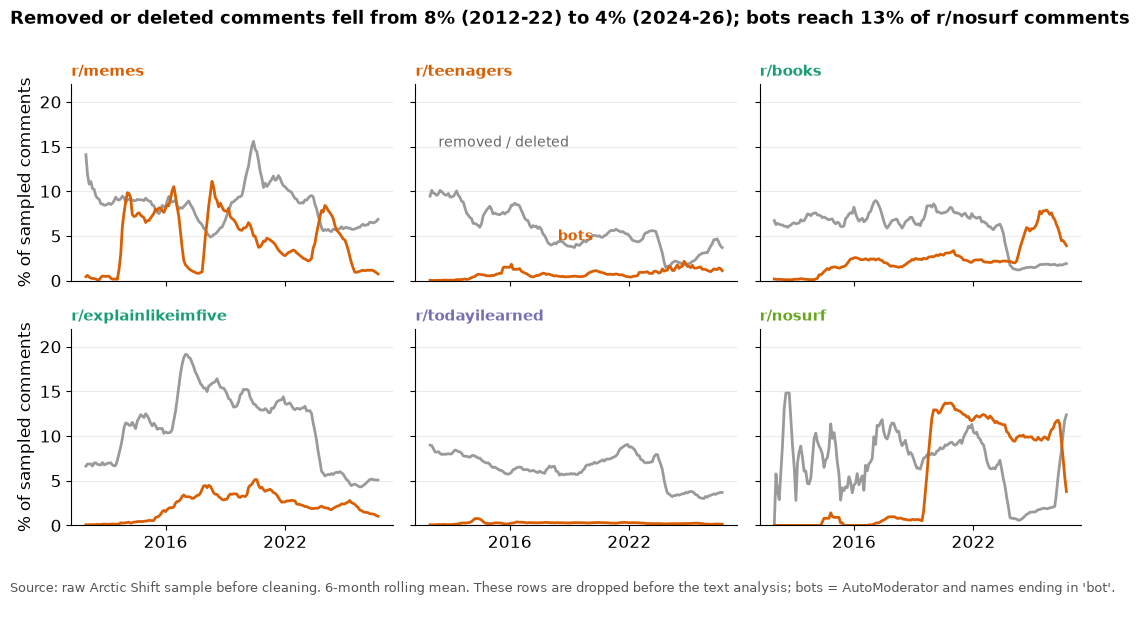

In [8]:
from src import figs_overview as figs
_ = figs.c03b()
plt.show()

**Code for C03b:** `src/figs_overview.py` function `c03b()`; reads `raw_quality_monthly`; built by `python run_pipeline.py aggregates`. All charts and tables: `docs/figure_index.md`, scripts explained in `docs/code_guide.md`.

### Q4. How concentrated is activity among authors?
**Why we asked:** A few heavy users can dominate a community's language, which matters for any text average.

**What we did:** Share of all messages (comments plus submissions) written by the most active x% of authors, log x-axis. r/nosurf (complete) is highlighted; the other five curves use only the sample.

**Result:** In r/nosurf the top 1% of authors write 24% of all messages. The sample-only curves of the other five subreddits give 15% to 29% at the same mark.

**Interpretation:** Activity is clearly skewed. The gray curves cannot be ranked against r/nosurf because sampling hides repeat posting, so true concentration there is probably higher.

**Next question:** How long are the comments these authors write?

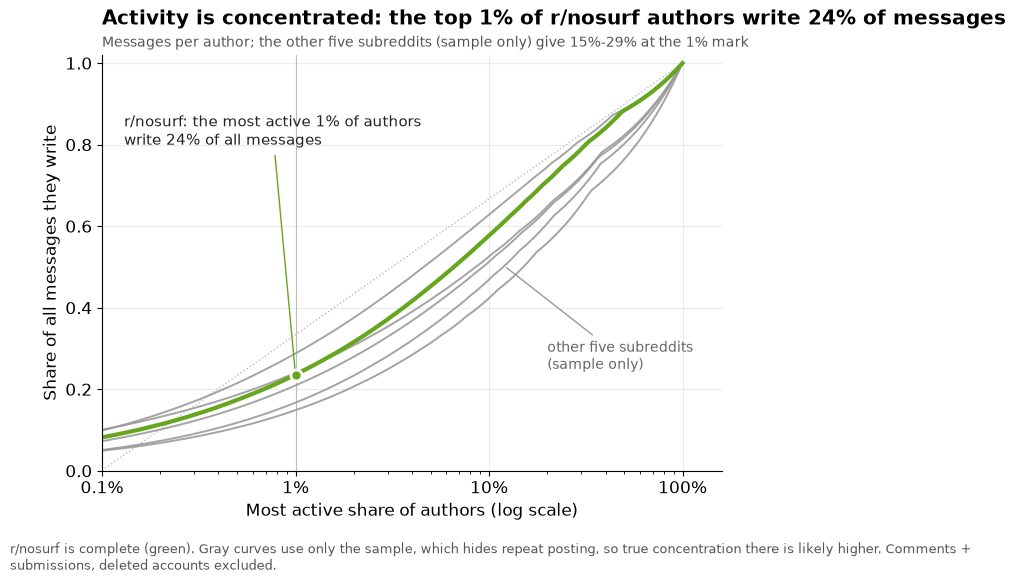

In [9]:
from src import figs_overview as figs
_ = figs.c04()
plt.show()

**Code for C04:** `src/figs_overview.py` function `c04()`; reads `author_activity`; built by `python run_pipeline.py aggregates`. All charts and tables: `docs/figure_index.md`, scripts explained in `docs/code_guide.md`.

### Q5. How long are comments in each subreddit?
**Why we asked:** H1 says discourse gets shorter; before testing change over time we need the level in each community.

**What we did:** Median (dot), middle half (thick bar) and 10th to 90th percentile (thin line) of comment length in words per subreddit (URLs removed), all years pooled, months weighted by true volume, log x-axis.

**Result:** Median comment length is 6 words in r/teenagers, 7 in r/memes, 16 in r/todayilearned, 26 in r/books, 29 in r/nosurf and 32 in r/explainlikeimfive.

**Interpretation:** The two short-form communities write comments about four to five times shorter than the long-form ones. This is a difference in level between communities, not yet a change over time; both groups also differ in topic and audience.

**Next question:** Has the length changed over time (C10, Phase 3)? First: when do people write?

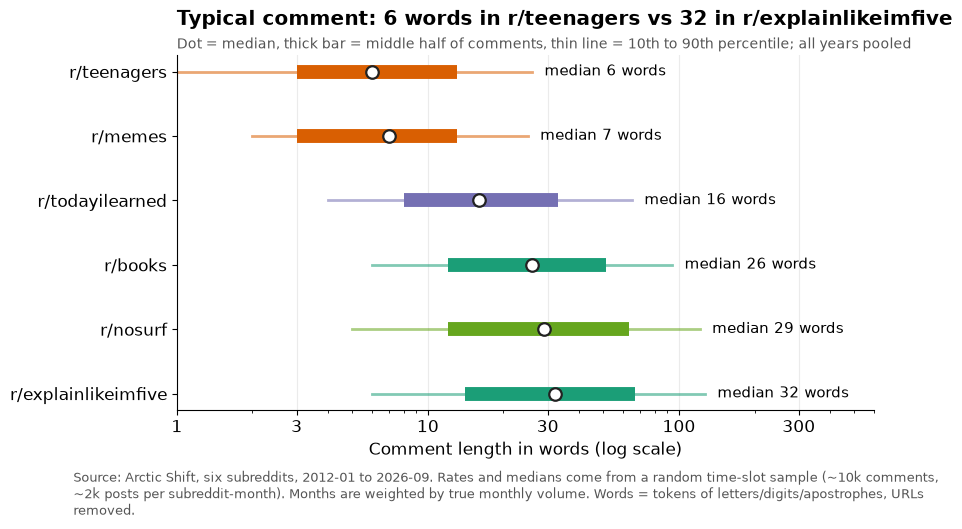

In [10]:
from src import figs_overview as figs
_ = figs.c05()
plt.show()

**Code for C05:** `src/figs_overview.py` function `c05()`; reads `length_hist`; built by `python run_pipeline.py aggregates`. All charts and tables: `docs/figure_index.md`, scripts explained in `docs/code_guide.md`.

### Q6. When do people write (UTC hour and weekday)?
**Why we asked:** Daily rhythm is the baseline for any behavioural claim (sessions, late-night activity).

**What we did:** Weighted comment counts by UTC weekday and hour, one heatmap per subreddit, shared BuGn color scale, smoothed over 3 hours because few sampled slots fall in each cell.

**Result:** Writing peaks around 16:00 UTC; a weekend day carries about 8% less than a weekday. All six communities are quietest between roughly 06:00 and 11:00 UTC.

**Interpretation:** The pattern fits a mostly US and European audience, but UTC mixes time zones, so hours cannot be read as users' local time. Cells for r/memes and r/teenagers are noisy because they rest on few slots.

**Next question:** Do conversations get deeper or shallower over time (Q7)?

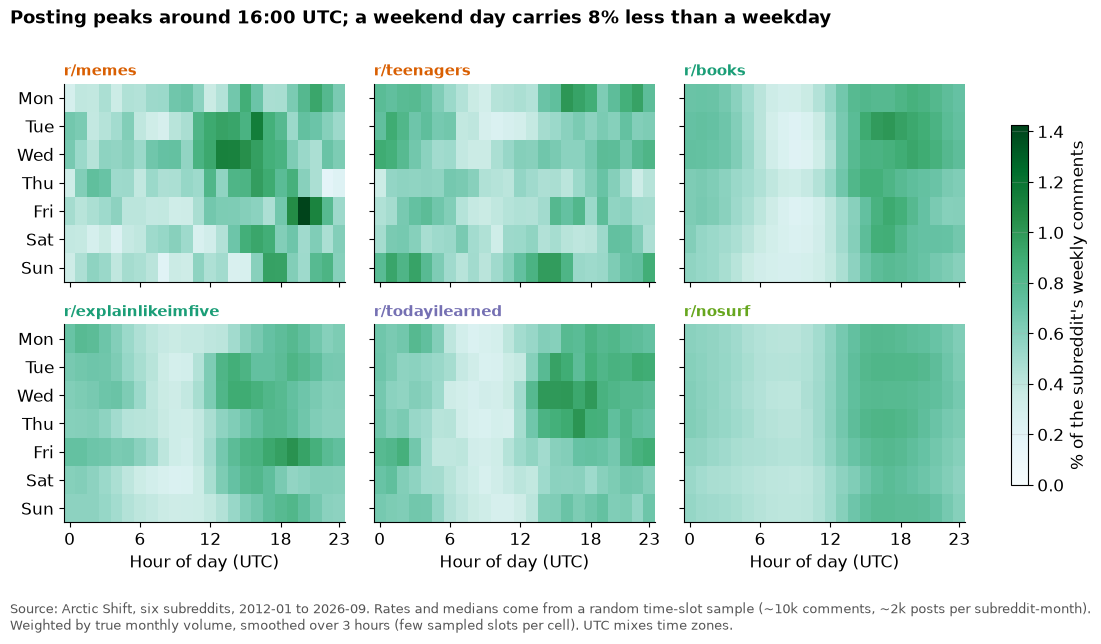

In [11]:
from src import figs_overview as figs
_ = figs.c06()
plt.show()

**Code for C06:** `src/figs_overview.py` function `c06()`; reads `hour_dow`; built by `python run_pipeline.py aggregates`. All charts and tables: `docs/figure_index.md`, scripts explained in `docs/code_guide.md`.

### Q7. How many comments does a post get, and has that changed?
**Why we asked:** A rising ratio means more discussion per post; a falling one means posts are consumed without replying.

**What we did:** Exact monthly comment total divided by exact submission total, per subreddit, 12-month mean, log y-axis.

**Result:** r/memes rose most, from 1.3 comments per post in 2015 to 20 in 2025. r/books fell from 13 to 10. r/todayilearned has the highest ratio from about 2015 on.

**Interpretation:** The ratio mixes how people comment and how people post. A feed full of image posts (r/memes in 2015) has few comments per post by design; the rise may reflect a different type of post, not more conversation.

**Next question:** Do upvotes follow length or quality at all (Q8)?

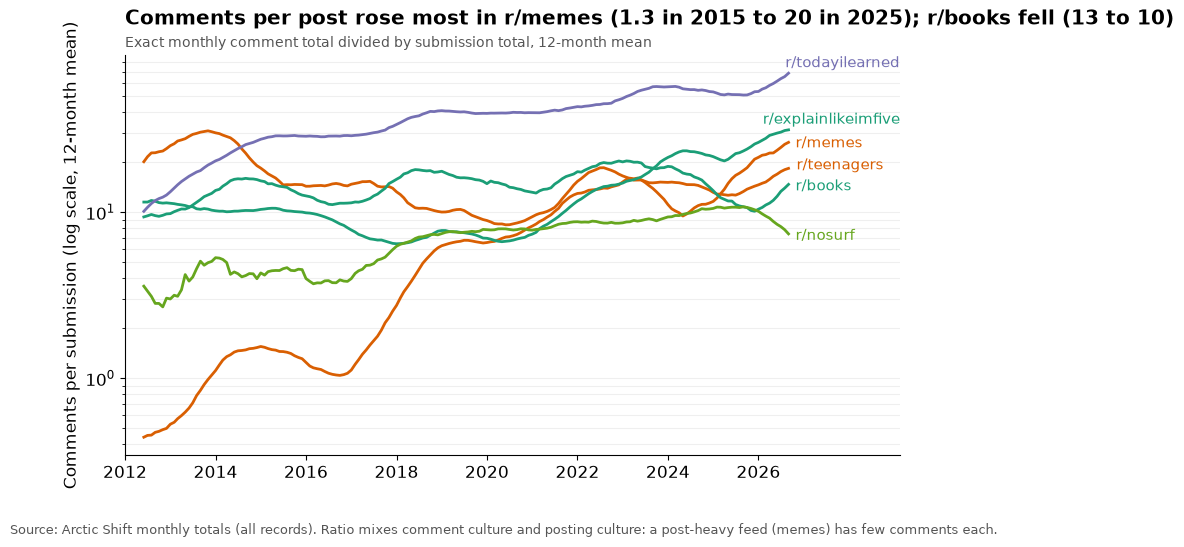

In [12]:
from src import figs_overview as figs
_ = figs.c07()
plt.show()

**Code for C07:** `src/figs_overview.py` function `c07()`; reads `monthly_totals`; built by `python run_pipeline.py aggregates`. All charts and tables: `docs/figure_index.md`, scripts explained in `docs/code_guide.md`.

### Q8. How are scores distributed, and do longer comments score higher?
**Why we asked:** Score is the only reaction signal we have; if it is mostly empty it cannot carry an analysis.

**What we did:** Share of comments by score band per subreddit, and the share of comments or submissions reaching a score of 10 by length bin (months weighted by volume).

**Result:** 45% to 60% of comments end at a score of 1 or less. Only 5% of 2-3-word comments reach 10 points, against 13% of comments with 32 or more words.

**Interpretation:** Most comments get no upvotes at all, so score is a weak signal outside a few viral comments. Scores are values at download time, not at posting time, so old and new months are not strictly comparable.

**Next question:** What happened on the days r/nosurf was unusually busy (Q9)?

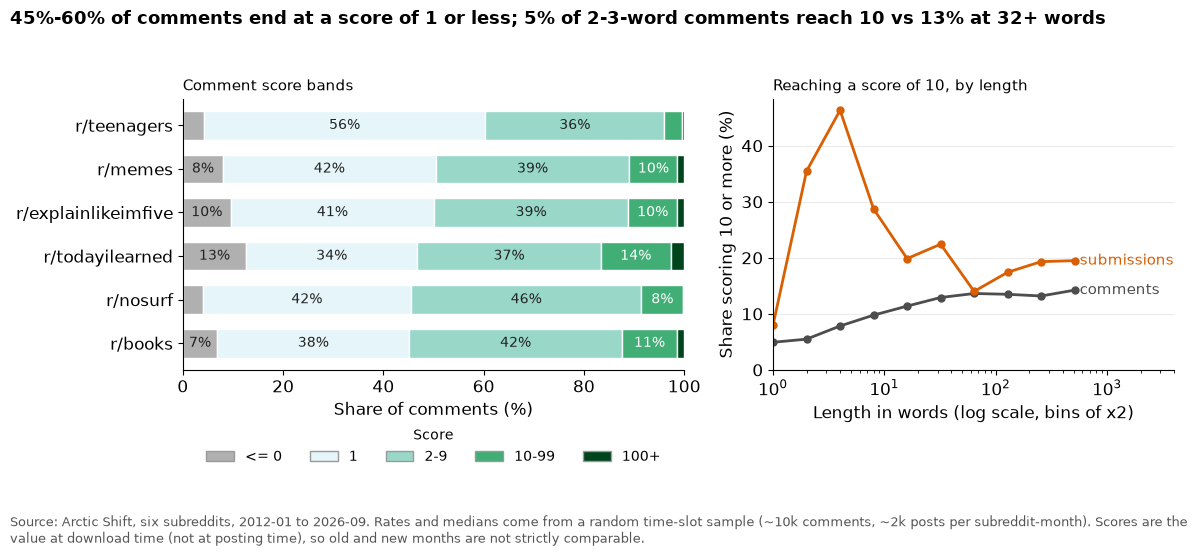

In [13]:
from src import figs_overview as figs
_ = figs.c08()
plt.show()

**Code for C08:** `src/figs_overview.py` function `c08()`; reads `score_hist`, `score_by_length`; built by `python run_pipeline.py aggregates`. All charts and tables: `docs/figure_index.md`, scripts explained in `docs/code_guide.md`.

### Q9. Which days were unusually busy in r/nosurf, and what happened?
**Why we asked:** Peaks are where real-world events show up; r/nosurf is the only subreddit with a complete daily series.

**What we did:** Daily comment counts with a 7-day mean; the five strongest one-day spikes (against a local 29-day median, in busy periods only) are marked, and the three crisis dates are drawn as dashed lines. For each spike we looked at which threads produced the extra comments.

**Result:** The busiest day was 11 September 2025 with 530 comments, 2.8 times the month before. Three threads carry 72% of that day's comments (a typical day: 43%); the two biggest (about 150 comments each in our data) were about the killing of Charlie Kirk, one of them titled by someone who saw it on a short-video feed. The other four marked spikes (30 December 2021, 25 January 2024, 22 March 2024, 19 December 2024) each have one thread with 89-122 comments, 28-33% of the day (on a typical day the biggest thread has 21%).

**Interpretation:** Spikes are single viral or news-driven threads, not platform-wide waves. The September 2025 spike is a clear single news shock inside our data range, in a subreddit about media use, with a direct link to short-form video, so it is a candidate event for H4. The three events chosen in advance (COVID-19, Ukraine, Gaza) show no spike at their date in this subreddit. An earlier version of this chart marked a fifth spike on 12 February 2021 (355 comments in 115 threads); it disappeared after the cleaning rules removed moderator removal notices and templated messages (243 comments left in 37 threads), so it was moderation, not discussion.

**Next question:** Do crises move language or mood in larger, non-news communities (H4)? That needs news subreddits and a control group.

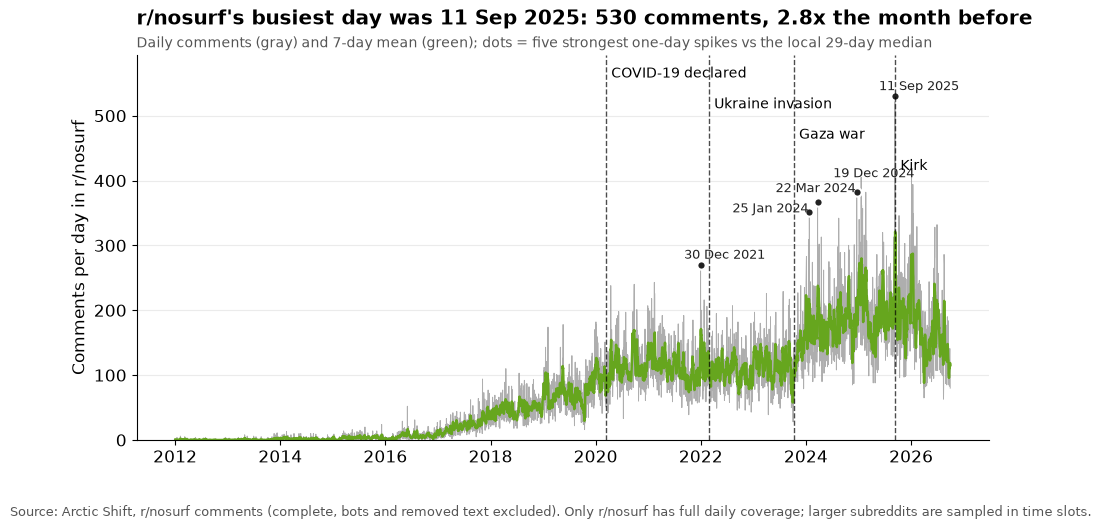

In [14]:
from src import figs_overview as figs
_ = figs.c09()
plt.show()

**Code for C09:** `src/figs_overview.py` function `c09()`; reads `daily_full_coverage`; built by `python run_pipeline.py aggregates`. All charts and tables: `docs/figure_index.md`, scripts explained in `docs/code_guide.md`.